<div align="center">

# 02 · Feature Engineering

</div>


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

def find_data_file(filename):
    paths = [
        Path.cwd() / "Data" / filename,
        Path.cwd().parent / "Data" / filename
    ]
    for path in paths:
        if path.is_file():
            return path
    raise FileNotFoundError(f"{filename} was not found in the project Data folder.")

DATA_PATH = find_data_file("Data_cleaned.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Loaded: d:\Sarthak's Folder\Project\Hackathon\Data\Data_cleaned.csv
Shape: 14,992 rows × 47 columns


In [2]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

ALIASES = {
    "batch_id": ["batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"],
    "timestamp": ["timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"],
    "machine_id": ["machine_id", "machine", "machine_no", "machine_number", "equipment_id"],
    "product_line": ["product_line", "production_line", "line", "line_id", "product"],
    "temperature": ["temperature", "temp", "temp_c", "temperature_c", "temperature_celsius"],
    "pressure": ["pressure", "press", "pressure_psi", "pressure_bar"],
    "cycle_time": ["cycle_time", "cycle_duration", "cycle_time_sec", "duration", "processing_time"],
    "vibration": ["vibration", "vibration_level", "vibration_mm_s", "vibration_rms"],
    "quality_measurement": ["quality_measurement", "quality_score", "quality", "quality_index"],
    "defect_rate": ["defect_rate", "defect_percentage", "defect_pct", "defect_ratio"],
    "actual_status": ["actual_status", "status", "process_status", "quality_status", "condition"],
    "final_outcome": ["final_outcome", "outcome", "result", "final_result", "decision"],
    "temperature_tolerance": ["temperature_tolerance", "temp_tolerance", "temperature_limit", "temp_limit"],
    "pressure_tolerance": ["pressure_tolerance", "pressure_limit", "pressure_upper_limit"],
    "cycle_time_tolerance": ["cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit"],
    "vibration_tolerance": ["vibration_tolerance", "vibration_limit", "vibration_upper_limit"]
}

def detect_column(concept):
    normalized = {normalize_name(c): c for c in df.columns}
    for alias in ALIASES.get(concept, []):
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]
    return None

COLUMN_MAP = {concept: detect_column(concept) for concept in ALIASES}
display(pd.DataFrame([{"concept": k, "column": v or "NOT FOUND"} for k, v in COLUMN_MAP.items()]))


,concept,column
0,batch_id,batch_id
1,timestamp,timestamp
2,machine_id,machine_id
3,product_line,product_line
4,temperature,temperature
5,pressure,pressure
6,cycle_time,cycle_time
7,vibration,vibration
8,quality_measurement,quality_measurement
9,defect_rate,defect_rate


# 01 · Prepare Production Order


In [3]:
timestamp_col = COLUMN_MAP.get("timestamp")
batch_col = COLUMN_MAP.get("batch_id")

if timestamp_col:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.dropna(subset=[timestamp_col]).sort_values(timestamp_col).reset_index(drop=True)
elif batch_col:
    df = df.sort_values(batch_col).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

df["_sequence"] = np.arange(len(df))
print(f"Ordered observations: {len(df):,}")


Ordered observations: 14,992


# 02 · Detect Core Process Variables


In [4]:
PROCESS_CONCEPTS = ["temperature", "pressure", "cycle_time", "vibration"]

available_process = {
    concept: COLUMN_MAP[concept]
    for concept in PROCESS_CONCEPTS
    if COLUMN_MAP.get(concept)
}

for concept in PROCESS_CONCEPTS:
    print(f"{concept}: {available_process.get(concept, 'NOT FOUND')}")


temperature: temperature
pressure: pressure
cycle_time: cycle_time
vibration: vibration


# 03 · Rolling Statistics


In [5]:
ROLLING_WINDOW = 25
MIN_PERIODS = max(5, ROLLING_WINDOW // 2)

for concept, col in available_process.items():
    value = pd.to_numeric(df[col], errors="coerce")
    df[f"{concept}_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()
    df[f"{concept}_rolling_std"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
    df[f"{concept}_rolling_variance"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).var()
    df[f"{concept}_deviation"] = value - df[f"{concept}_rolling_mean"]
    df[f"{concept}_rolling_z"] = df[f"{concept}_deviation"] / df[f"{concept}_rolling_std"].replace(0, np.nan)

print("Rolling features created.")


Rolling features created.


# 04 · Change Features


In [6]:
for concept, col in available_process.items():
    value = pd.to_numeric(df[col], errors="coerce")
    df[f"{concept}_change"] = value.diff()
    df[f"{concept}_pct_change"] = value.pct_change() * 100
    df[f"{concept}_baseline_pct_change"] = (
        (value - df[f"{concept}_rolling_mean"])
        / df[f"{concept}_rolling_mean"].replace(0, np.nan)
        * 100
    )

print("Change features created.")


Change features created.


# 05 · Tolerance Features


In [7]:
TOLERANCE_PAIRS = {
    "temperature": "temperature_tolerance",
    "pressure": "pressure_tolerance",
    "cycle_time": "cycle_time_tolerance",
    "vibration": "vibration_tolerance"
}

for concept, tolerance_concept in TOLERANCE_PAIRS.items():
    value_col = COLUMN_MAP.get(concept)
    tolerance_col = COLUMN_MAP.get(tolerance_concept)

    if not value_col or not tolerance_col:
        continue

    value = pd.to_numeric(df[value_col], errors="coerce")
    tolerance = pd.to_numeric(df[tolerance_col], errors="coerce")

    df[f"{concept}_tolerance_distance"] = tolerance - value
    df[f"{concept}_tolerance_utilization_pct"] = value / tolerance.replace(0, np.nan) * 100
    df[f"{concept}_near_limit"] = df[f"{concept}_tolerance_utilization_pct"] >= 90

print("Tolerance features created.")


Tolerance features created.


# 06 · Quality and Defect Features

In [8]:
quality_col = COLUMN_MAP.get("quality_measurement")
defect_col = COLUMN_MAP.get("defect_rate")

if quality_col:
    value = pd.to_numeric(df[quality_col], errors="coerce")
    df["quality_change"] = value.diff()
    df["quality_pct_change"] = value.pct_change() * 100
    df["quality_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()

if defect_col:
    value = pd.to_numeric(df[defect_col], errors="coerce")
    df["defect_rate_change"] = value.diff()
    df["defect_rate_pct_change"] = value.pct_change() * 100
    df["defect_rate_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()

print("Quality and defect features created.")


Quality and defect features created.


# 07 · Feature Audit

In [9]:
feature_cols = [
    c for c in df.columns
    if any(token in c for token in [
        "_rolling_", "_change", "_pct_change", "_deviation",
        "_tolerance_", "_near_limit", "_baseline_"
    ])
]

feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(df[c].dtype) for c in feature_cols],
    "missing": [int(df[c].isna().sum()) for c in feature_cols],
    "unique": [int(df[c].nunique(dropna=True)) for c in feature_cols]
})

display(feature_audit)


,feature,dtype,missing,unique
0,temperature_tolerance_distance,float64,0,6839
1,pressure_tolerance_distance,float64,0,7102
2,cycle_time_tolerance_distance,float64,0,5679
3,vibration_tolerance_distance,float64,0,2371
4,temperature_rolling_mean,float64,11,13834
5,temperature_rolling_std,float64,11,14978
6,temperature_rolling_z,float64,11,14981
7,pressure_rolling_mean,float64,11,13953
8,pressure_rolling_std,float64,11,14980
9,pressure_rolling_z,float64,11,14981


# 08 · Feature Visualization

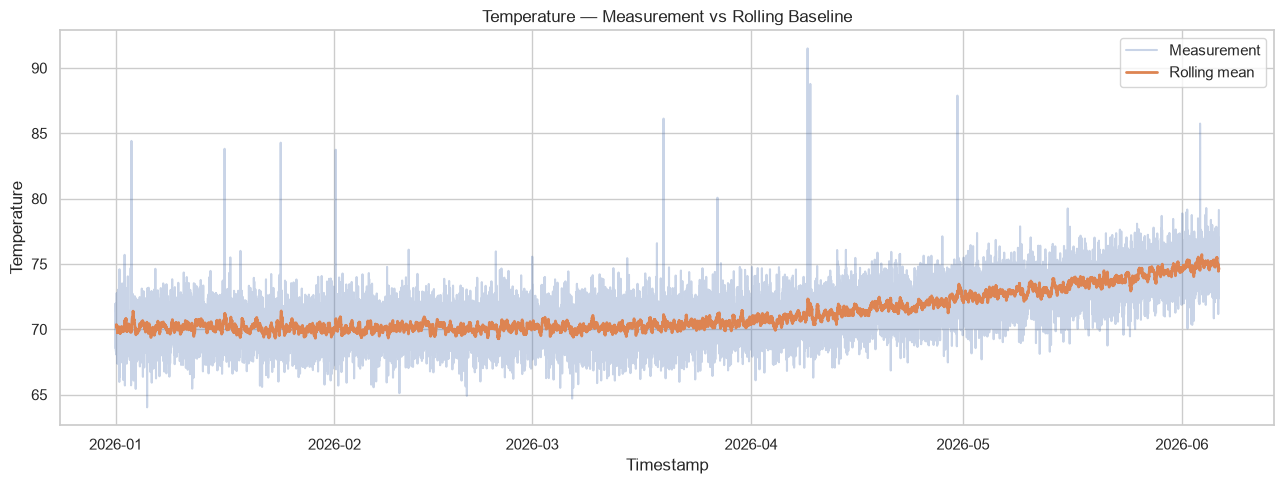

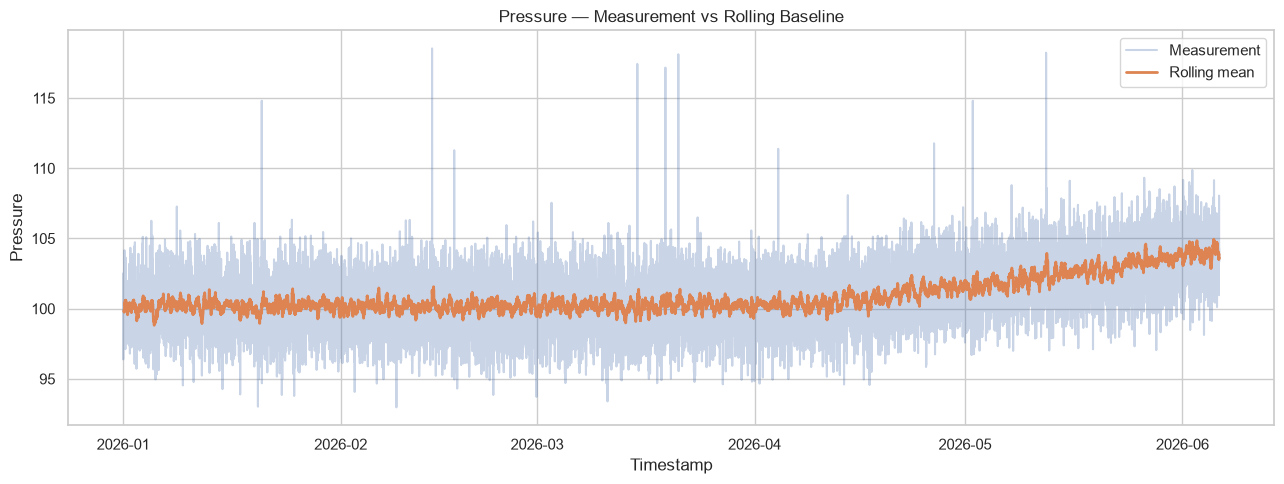

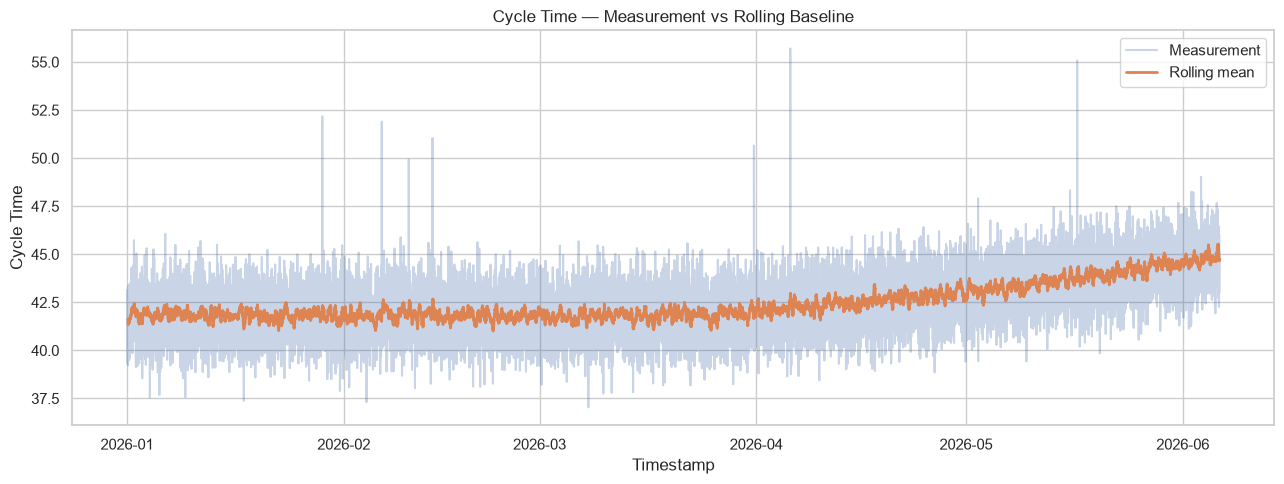

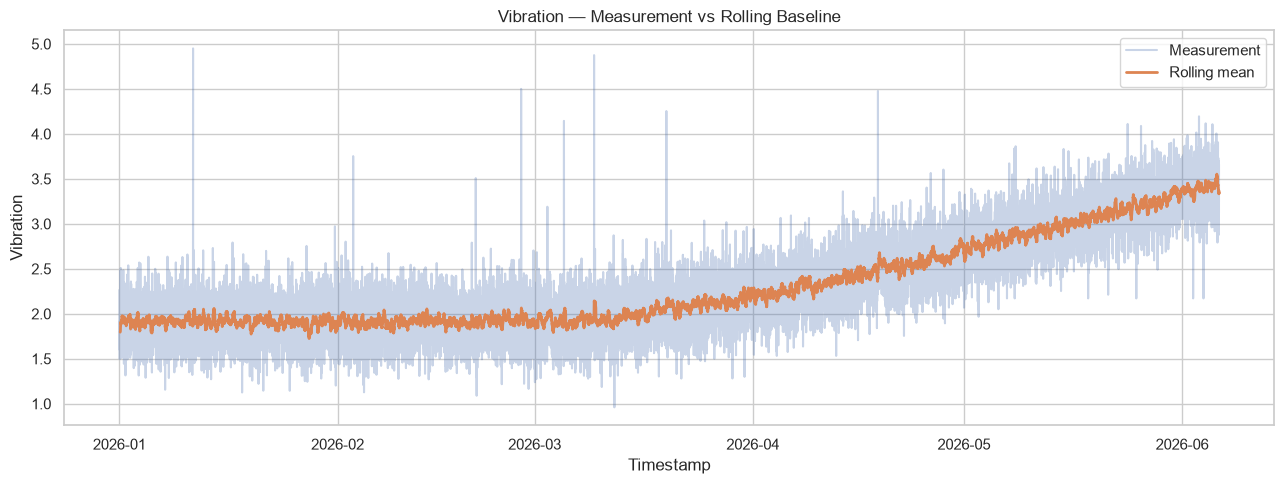

In [10]:
for concept, col in available_process.items():
    x = df[timestamp_col] if timestamp_col and timestamp_col in df.columns else df["_sequence"]

    plt.figure(figsize=(13, 5))
    plt.plot(x, df[col], alpha=0.30, label="Measurement")
    plt.plot(x, df[f"{concept}_rolling_mean"], linewidth=2, label="Rolling mean")
    plt.title(f"{concept.replace('_', ' ').title()} — Measurement vs Rolling Baseline")
    plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
    plt.ylabel(col.replace("_", " ").title())
    plt.legend()
    plt.tight_layout()
    plt.show()


# 09 · Export Feature Dataset

In [11]:
output_path = DATA_PATH.parent / "Data_features.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Saved: d:\Sarthak's Folder\Project\Hackathon\Data\Data_features.csv
Shape: 14,992 rows × 82 columns
